# **Lab 05.2 - Continuous and Policy-Based RL with DDPG and PPO**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
  
This lab contains the following practical parts:
1. Part 1,2 — Build and validate the EdgeOffloadingEnv (device vs. edge).
2. Part 3 — Implement baseline policies (random, device-only, edge-only, greedy).
3. Part 4 — A2C
4. Part 5 — PPO
6. Part 6 — Final comparison and analysis of all methods.


In [1]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = True
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cpu
PyTorch: 2.5.1
NumPy: 2.0.1
Gymnasium: 1.2.2
FAST_MODE: True


In [2]:
print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.
    
    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency (minimizing latency)
    """

    metadata = {'render_modes': ['human']}

    def __init__(self, max_steps=50):
        """Initialize environment parameters.
        
        Args:
            max_steps: Maximum steps per episode
        """
        super().__init__()
        
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.f_device = 1.0
        self.f_edge = 5.0
        self.max_steps = max_steps
        low = np.array([1.0, 0.1, 2.0, 0.0], dtype=np.float32)
        high = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = spaces.Discrete(2)
        self.state = None
        self.step_count = 0

    def _sample_state(self):
        """Sample a new random state.
        
        Returns:
            State array: [input_size, workload, uplink_rate, edge_queue]
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size = self.np_random.uniform(1.0, 20.0)
        workload = self.np_random.uniform(0.1, 3.0)
        uplink_rate = self.np_random.uniform(2.0, 20.0)
        edge_queue = self.np_random.uniform(0.0, 200.0)
        return np.array([input_size, workload, uplink_rate, edge_queue], dtype=np.float32)

    def _compute_latencies(self, state):
        """Compute execution latencies for device and edge.
        
        Args:
            state: Current state [input_size, workload, uplink_rate, edge_queue]
            
        Returns:
            Tuple (latency_device, latency_edge) in milliseconds
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size, workload, uplink_rate, edge_queue = np.asarray(state, dtype=np.float32)
        latency_device = workload / self.f_device * 1000.0
        upload_latency = input_size / uplink_rate * 1000.0
        latency_edge = upload_latency + edge_queue + workload / self.f_edge * 1000.0
        return float(latency_device), float(latency_edge)

    def reset(self, seed=None, options=None):
        """Reset environment to initial state.
        
        Args:
            seed: Random seed for reproducibility
            options: Additional reset options
            
        Returns:
            Tuple (observation, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        super().reset(seed=seed)
        self.step_count = 0
        self.state = self._sample_state()
        return self.state.copy(), {}

    def step(self, action):
        """Execute one step in the environment.
        
        Args:
            action: 0 for device execution, 1 for edge offloading
            
        Returns:
            Tuple (observation, reward, terminated, truncated, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = int(action)
        assert self.action_space.contains(action), f"Invalid action: {action}"
        latency_device, latency_edge = self._compute_latencies(self.state)
        selected_latency = latency_device if action == 0 else latency_edge
        action_name = 'device' if action == 0 else 'edge'
        reward = -selected_latency / 1000.0
        self.step_count += 1
        terminated = False
        truncated = self.step_count >= self.max_steps
        info = {
            'latency': selected_latency,
            'latency_device': latency_device,
            'latency_edge': latency_edge,
            'action': action,
            'action_name': action_name,
        }
        self.state = self._sample_state()
        return self.state.copy(), reward, terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')



PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [ 15.705   1.373  17.455 139.474]
Initial info: {}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [3]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
✓ check_env passed successfully.

Test rollout (5 steps):
Initial obs: [ 15.705   1.373  17.455 139.474]
Step 1: action=1, reward=-1.313787, latency=1313.79ms, action_name=edge
Step 2: action=1, reward=-0.920735, latency=920.73ms, action_name=edge
Step 3: action=0, reward=-1.406119, latency=1406.12ms, action_name=device
Step 4: action=1, reward=-1.868452, latency=1868.45ms, action_name=edge
Step 5: action=0, reward=-0.285070, latency=285.07ms, action_name=device


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [4]:
# ============================================================================
# Baseline policy functions
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def random_policy(state, env):
    return env.action_space.sample()


def device_only_policy(state, env):
    return 0


def edge_only_policy(state, env):
    return 1


def greedy_latency_policy(state, env):
    latency_device, latency_edge = env._compute_latencies(state)
    return 0 if latency_device <= latency_edge else 1


In [5]:
# ============================================================================
# Evaluate baseline policies
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def make_env(seed):
    env = EdgeOffloadingEnv(max_steps=50)
    env.action_space.seed(seed)
    return env


baseline_policies = {
    'Random': random_policy,
    'Device-only': device_only_policy,
    'Edge-only': edge_only_policy,
    'Greedy latency': greedy_latency_policy,
}

edge_evaluation_episodes = 200 if FAST_MODE else 500
edge_convergence_gap_tolerance_ms = 25.0
print(f'Convergence check: trained policies must satisfy 0 <= GapToGreedy <= {edge_convergence_gap_tolerance_ms:.1f} ms before comparison.')

baseline_results = {}
for policy_name, policy_function in baseline_policies.items():
    baseline_results[policy_name] = evaluate_edge_policy(make_env, policy_function, episodes=edge_evaluation_episodes)
    result = baseline_results[policy_name]
    print(f"{policy_name:15s} | Avg Latency: {result['avg_latency']:.2f} ms | P95: {result['p95_latency']:.2f} ms | Avg Reward: {result['avg_reward']:.4f} | Device%: {result['device_pct']:.1f} | Edge%: {result['edge_pct']:.1f}")


Convergence check: trained policies must satisfy 0 <= GapToGreedy <= 25.0 ms before comparison.
Random          | Avg Latency: 1627.18 ms | P95: 3183.58 ms | Avg Reward: -81.3592 | Device%: 50.1 | Edge%: 49.9
Device-only     | Avg Latency: 1537.57 ms | P95: 2843.95 ms | Avg Reward: -76.8787 | Device%: 100.0 | Edge%: 0.0
Edge-only       | Avg Latency: 1734.45 ms | P95: 4408.80 ms | Avg Reward: -86.7225 | Device%: 0.0 | Edge%: 100.0
Greedy latency  | Avg Latency: 1124.04 ms | P95: 2339.02 ms | Avg Reward: -56.2022 | Device%: 48.5 | Edge%: 51.4


---

# PART 4: A2C 


### 6.1 A2C Training and Evaluation


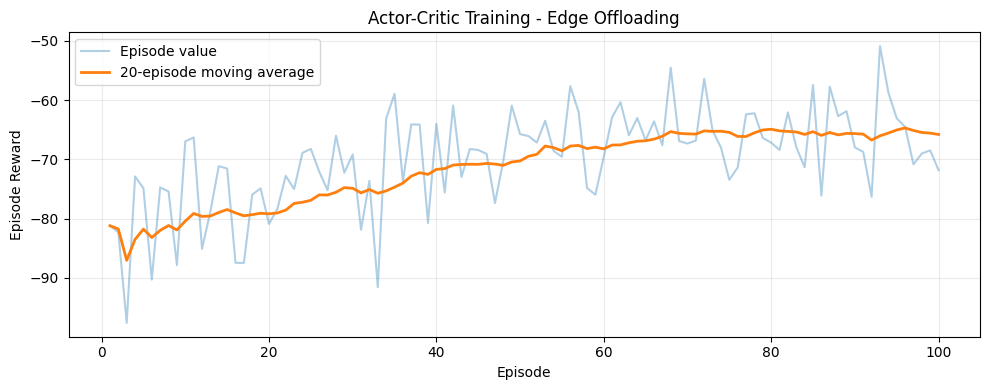

Actor-Critic | Avg Latency: 1138.65 ms | P95: 2365.28 ms | Avg Reward: -56.9324 | Device%: 45.7 | Edge%: 54.3


In [6]:
# ============================================================================
# Actor-Critic training analysis
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
OBS_LOW = np.array([1.0, 0.1, 2.0, 0.0], dtype=np.float32)
OBS_HIGH = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)


def normalize_state(state):
    return (np.asarray(state, dtype=np.float32) - OBS_LOW) / (OBS_HIGH - OBS_LOW)


class ActorNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        return self.net(x)


class CriticNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_actor_critic_offloading(num_episodes=300, gamma=0.95, actor_lr=5e-4, critic_lr=1e-3, entropy_coef=0.01):
    actor = ActorNetwork().to(device)
    critic = CriticNetwork().to(device)
    actor_optimizer = optim.Adam(actor.parameters(), lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)
    env = EdgeOffloadingEnv(max_steps=50)
    episode_returns = []

    for episode_index in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode_index)
        done = False
        episode_return = 0.0

        while not done:
            state_tensor = torch.tensor(normalize_state(state), dtype=torch.float32, device=device).unsqueeze(0)
            probabilities = actor(state_tensor).squeeze(0)
            distribution = Categorical(probabilities)
            action_tensor = distribution.sample()
            log_probability = distribution.log_prob(action_tensor)
            value = critic(state_tensor)
            next_state, reward, terminated, truncated, _ = env.step(int(action_tensor.item()))
            done = terminated or truncated
            next_state_tensor = torch.tensor(normalize_state(next_state), dtype=torch.float32, device=device).unsqueeze(0)
            reward_tensor = torch.tensor(reward, dtype=torch.float32, device=device)

            with torch.no_grad():
                next_value = torch.tensor(0.0, dtype=torch.float32, device=device) if done else critic(next_state_tensor)

            td_error = reward_tensor + gamma * next_value - value
            critic_loss = td_error.pow(2).mean()
            actor_loss = -(log_probability * td_error.detach()) - entropy_coef * distribution.entropy()

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            episode_return += reward
            state = next_state

        episode_returns.append(float(episode_return))

    env.close()
    return actor, np.asarray(episode_returns, dtype=np.float32)


actor_critic_episodes = 100 if FAST_MODE else 1000
actor_critic_actor, actor_critic_rewards = train_actor_critic_offloading(num_episodes=actor_critic_episodes)
plot_curve(actor_critic_rewards, 'Actor-Critic Training - Edge Offloading', 'Episode Reward', window=20)


def actor_critic_action_fn(state, env):
    state_tensor = torch.tensor(normalize_state(state), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        probabilities = actor_critic_actor(state_tensor).squeeze(0)
    return int(torch.argmax(probabilities).item())


actor_critic_result = evaluate_edge_policy(make_env, actor_critic_action_fn, episodes=edge_evaluation_episodes)
print(f"Actor-Critic | Avg Latency: {actor_critic_result['avg_latency']:.2f} ms | P95: {actor_critic_result['p95_latency']:.2f} ms | Avg Reward: {actor_critic_result['avg_reward']:.4f} | Device%: {actor_critic_result['device_pct']:.1f} | Edge%: {actor_critic_result['edge_pct']:.1f}")



PART 5: A2C (OPTIONAL, STABLE-BASELINES3)


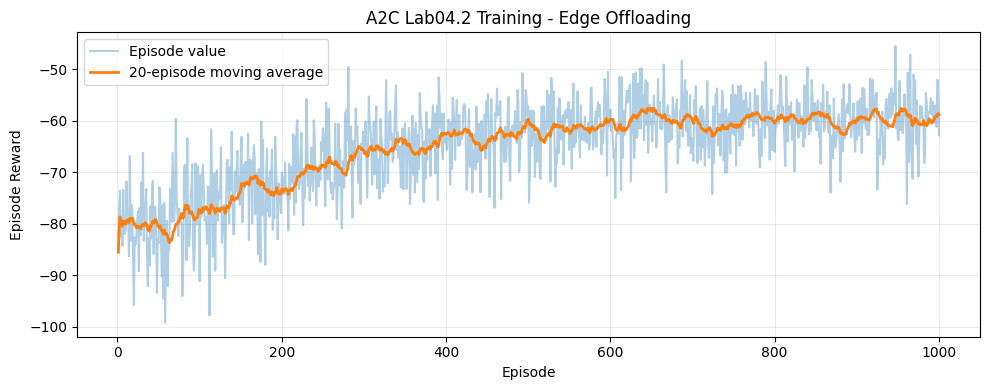

A2C (Lab04.2) | Avg Latency: 1137.12 ms | P95: 2367.33 ms | Avg Reward: -56.8561 | Device%: 47.6 | Edge%: 52.4


In [7]:
print("\n" + "="*60)
print("PART 5: A2C (OPTIONAL, STABLE-BASELINES3)")
print("="*60)

# ============================================================================
# A2C training and evaluation
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def train_a2c_offloading(episodes=400, gamma=0.0, actor_lr=3e-4, critic_lr=1e-3, entropy_coef=0.03):
    actor = ActorNetwork(input_dim=4, hidden_dim=128, output_dim=2).to(device)
    critic = CriticNetwork(input_dim=4, hidden_dim=128).to(device)
    actor_optimizer = optim.Adam(actor.parameters(), lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)
    env = EdgeOffloadingEnv(max_steps=50)
    episode_returns = []

    for episode_index in range(episodes):
        state, _ = env.reset(seed=SEED + 5000 + episode_index)
        done = False
        total_reward = 0.0
        log_probabilities = []
        rewards = []
        values = []
        entropies = []

        while not done:
            state_tensor = torch.tensor(normalize_state(state), dtype=torch.float32, device=device).unsqueeze(0)
            probabilities = actor(state_tensor).squeeze(0)
            value = critic(state_tensor).squeeze(0)
            distribution = Categorical(probabilities)
            action_tensor = distribution.sample()
            next_state, reward, terminated, truncated, _ = env.step(int(action_tensor.item()))
            done = terminated or truncated
            log_probabilities.append(distribution.log_prob(action_tensor))
            rewards.append(float(reward))
            values.append(value)
            entropies.append(distribution.entropy())
            total_reward += reward
            state = next_state

        returns = []
        running_return = 0.0
        for reward_value in reversed(rewards):
            running_return = reward_value + gamma * running_return
            returns.insert(0, running_return)

        returns_tensor = torch.tensor(returns, dtype=torch.float32, device=device)
        values_tensor = torch.stack(values)
        log_probabilities_tensor = torch.stack(log_probabilities)
        entropies_tensor = torch.stack(entropies)
        advantages = returns_tensor - values_tensor.detach()
        if advantages.std() > 1e-8:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        actor_loss = -(log_probabilities_tensor * advantages).mean() - entropy_coef * entropies_tensor.mean()
        critic_loss = nn.functional.mse_loss(values_tensor, returns_tensor)

        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()

        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

        episode_returns.append(float(total_reward))

    env.close()
    return actor, np.asarray(episode_returns, dtype=np.float32)


a2c_episodes = 1000 if FAST_MODE else 1200
a2c_lab4_actor, a2c_lab4_rewards = train_a2c_offloading(episodes=a2c_episodes)
plot_curve(a2c_lab4_rewards, 'A2C Lab04.2 Training - Edge Offloading', 'Episode Reward', window=20)


def a2c_lab4_action_fn(state, env):
    state_tensor = torch.tensor(normalize_state(state), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        probabilities = a2c_lab4_actor(state_tensor).squeeze(0)
    return int(torch.argmax(probabilities).item())


a2c_lab4_result = evaluate_edge_policy(make_env, a2c_lab4_action_fn, episodes=edge_evaluation_episodes)
print(f"A2C (Lab04.2) | Avg Latency: {a2c_lab4_result['avg_latency']:.2f} ms | P95: {a2c_lab4_result['p95_latency']:.2f} ms | Avg Reward: {a2c_lab4_result['avg_reward']:.4f} | Device%: {a2c_lab4_result['device_pct']:.1f} | Edge%: {a2c_lab4_result['edge_pct']:.1f}")


---

# PART 5: PPO on EdgeOffloadingEnv

**Pipeline Architecture**:
1. Feed edge state tensors into shared feature blocks.
2. Produce offloading-action logits via `ppo_scratch_policy_net`.
3. Produce scalar baseline via `ppo_scratch_value_net`.
4. Sample actions from Categorical logits for on-policy exploration.

**Component Interactions**:
- Policy and value heads share encoded system-state features.
- Outputs are consumed by rollout collection and PPO optimization below.

**Mathematical/Algorithmic Anchors**:
- Categorical stochastic policy over offloading decisions.
- Baseline value estimate for advantage reduction.



PART 4: PPO ON EDGE OFFLOADING ENV


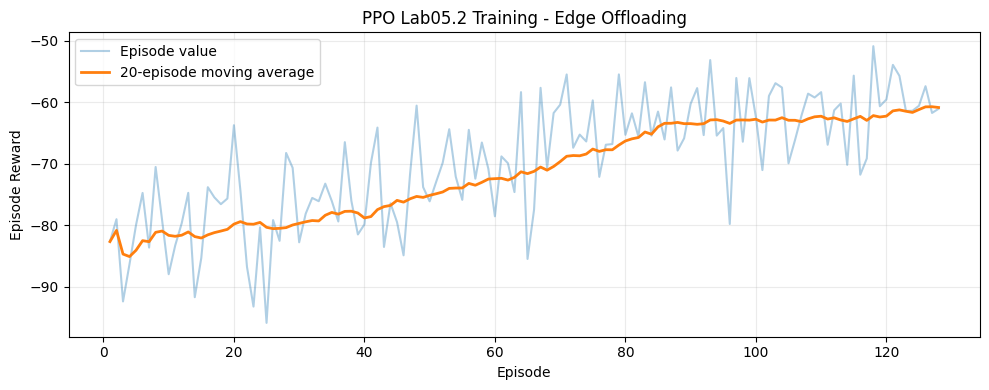

PPO (Lab05.2) | Avg Latency: 1141.12 ms | P95: 2392.60 ms | Avg Reward: -57.0562 | Device%: 49.1 | Edge%: 50.9


In [8]:
print("\n" + "="*60)
print("PART 4: PPO ON EDGE OFFLOADING ENV")
print("="*60)

# ============================================================================
# PPO Networks
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
class EdgeRolloutBuffer:
    def __init__(self):
        self.clear()

    def clear(self):
        self.states = []
        self.actions = []
        self.log_probabilities = []
        self.rewards = []
        self.dones = []
        self.values = []

    def add(self, state, action, log_probability, reward, done, value):
        self.states.append(normalize_state(state))
        self.actions.append(int(action))
        self.log_probabilities.append(float(log_probability))
        self.rewards.append(float(reward))
        self.dones.append(float(done))
        self.values.append(float(value))


class EdgePPONetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.policy_head = nn.Linear(hidden_dim, output_dim)
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, state_tensor):
        latent = self.shared(state_tensor)
        return self.policy_head(latent), self.value_head(latent)


def compute_edge_gae(rewards, dones, values, gamma=0.0, gae_lambda=0.95):
    advantages = []
    running_advantage = 0.0
    extended_values = list(values) + [0.0]
    for index in reversed(range(len(rewards))):
        delta = rewards[index] + gamma * extended_values[index + 1] * (1.0 - dones[index]) - extended_values[index]
        running_advantage = delta + gamma * gae_lambda * (1.0 - dones[index]) * running_advantage
        advantages.insert(0, running_advantage)
    advantages = np.asarray(advantages, dtype=np.float32)
    returns = advantages + np.asarray(values, dtype=np.float32)
    return advantages, returns


class EdgePPOTrainer:
    def __init__(self, learning_rate=3e-4, clip_ratio=0.2):
        self.network = EdgePPONetwork().to(device)
        self.optimizer = optim.Adam(self.network.parameters(), lr=learning_rate)
        self.clip_ratio = clip_ratio

    def sample_action(self, state):
        state_tensor = torch.tensor(normalize_state(state), dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            logits, value = self.network(state_tensor)
            distribution = Categorical(logits=logits)
            action_tensor = distribution.sample()
            log_probability = distribution.log_prob(action_tensor)
        return int(action_tensor.item()), float(log_probability.item()), float(value.item())

    def greedy_action(self, state):
        state_tensor = torch.tensor(normalize_state(state), dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            logits, _ = self.network(state_tensor)
        return int(torch.argmax(logits, dim=1).item())

    def optimize(self, rollout_buffer, gamma=0.0, gae_lambda=0.95, epochs=4, minibatch_size=128):
        state_tensor = torch.tensor(np.asarray(rollout_buffer.states), dtype=torch.float32, device=device)
        action_tensor = torch.tensor(rollout_buffer.actions, dtype=torch.long, device=device)
        old_log_probability_tensor = torch.tensor(rollout_buffer.log_probabilities, dtype=torch.float32, device=device)
        advantages, returns = compute_edge_gae(rollout_buffer.rewards, rollout_buffer.dones, rollout_buffer.values, gamma=gamma, gae_lambda=gae_lambda)
        advantage_tensor = torch.tensor(advantages, dtype=torch.float32, device=device)
        return_tensor = torch.tensor(returns, dtype=torch.float32, device=device).unsqueeze(1)
        advantage_tensor = (advantage_tensor - advantage_tensor.mean()) / (advantage_tensor.std() + 1e-8)
        sample_count = state_tensor.shape[0]
        indices = np.arange(sample_count)

        for _ in range(epochs):
            np.random.shuffle(indices)
            for start in range(0, sample_count, minibatch_size):
                batch_indices = indices[start:start + minibatch_size]
                batch_states = state_tensor[batch_indices]
                batch_actions = action_tensor[batch_indices]
                batch_old_log_probabilities = old_log_probability_tensor[batch_indices]
                batch_advantages = advantage_tensor[batch_indices]
                batch_returns = return_tensor[batch_indices]
                logits, values = self.network(batch_states)
                distribution = Categorical(logits=logits)
                new_log_probabilities = distribution.log_prob(batch_actions)
                ratio = torch.exp(new_log_probabilities - batch_old_log_probabilities)
                unclipped = ratio * batch_advantages
                clipped = torch.clamp(ratio, 1.0 - self.clip_ratio, 1.0 + self.clip_ratio) * batch_advantages
                policy_loss = -torch.min(unclipped, clipped).mean()
                value_loss = nn.functional.mse_loss(values, batch_returns)
                entropy_bonus = distribution.entropy().mean()
                loss = policy_loss + 0.5 * value_loss - 0.01 * entropy_bonus
                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.network.parameters(), 0.5)
                self.optimizer.step()


def train_edge_ppo(epochs=40, rollout_steps=512, clip_ratio=0.2, gae_lambda=0.95):
    trainer = EdgePPOTrainer(learning_rate=3e-4, clip_ratio=clip_ratio)
    rollout_buffer = EdgeRolloutBuffer()
    env = EdgeOffloadingEnv(max_steps=50)
    training_returns = []
    observation, _ = env.reset(seed=SEED + 8000)
    episode_return = 0.0

    for epoch_index in range(epochs):
        rollout_buffer.clear()
        epoch_return = 0.0
        for step_index in range(rollout_steps):
            action, log_probability, value = trainer.sample_action(observation)
            next_observation, reward, terminated, truncated, _ = env.step(action)
            done = float(terminated or truncated)
            rollout_buffer.add(observation, action, log_probability, reward, done, value)
            epoch_return += reward
            episode_return += reward
            observation = next_observation
            if terminated or truncated:
                training_returns.append(float(episode_return))
                episode_return = 0.0
                observation, _ = env.reset(seed=SEED + 8000 + epoch_index + step_index)
        trainer.optimize(rollout_buffer, gamma=0.0, gae_lambda=gae_lambda, epochs=4, minibatch_size=128)
        if len(training_returns) == 0:
            training_returns.append(float(epoch_return))

    env.close()
    return trainer, np.asarray(training_returns, dtype=np.float32)


ppo_epochs = 25 if FAST_MODE else 90
ppo_rollout_steps = 256 if FAST_MODE else 512
edge_ppo_trainer, edge_ppo_rewards = train_edge_ppo(epochs=ppo_epochs, rollout_steps=ppo_rollout_steps, clip_ratio=0.2, gae_lambda=0.95)
plot_curve(edge_ppo_rewards, 'PPO Lab05.2 Training - Edge Offloading', 'Episode Reward', window=20)


def ppo_edge_action_fn(state, env):
    return edge_ppo_trainer.greedy_action(state)


ppo_edge_result = evaluate_edge_policy(make_env, ppo_edge_action_fn, episodes=edge_evaluation_episodes)
print(f"PPO (Lab05.2) | Avg Latency: {ppo_edge_result['avg_latency']:.2f} ms | P95: {ppo_edge_result['p95_latency']:.2f} ms | Avg Reward: {ppo_edge_result['avg_reward']:.4f} | Device%: {ppo_edge_result['device_pct']:.1f} | Edge%: {ppo_edge_result['edge_pct']:.1f}")


---

# PART 6: Final Comparison

We compare all methods (baseline policies, Actor-Critic, and A2C) using shared evaluation metrics.

### 6.1 Aggregated Results Table



TRAINED POLICY CONVERGENCE CHECK
               AvgLatency  GapToGreedy  Converged
Method                                           
Actor-Critic     1138.647       14.603       True
A2C (Lab04.2)    1137.122       13.078       True
PPO (Lab05.2)    1141.124       17.080       True
                AvgLatency  P95Latency  AvgReward  StdReturn  MaxReturn  Device %  Edge %  GapToGreedy
Method                                                                                                
Random            1627.184    3183.585    -81.359      7.294    -63.205     50.09   49.91      503.140
Device-only       1537.573    2843.950    -76.879      6.031    -60.595    100.00    0.00      413.529
Edge-only         1734.450    4408.800    -86.722      9.231    -62.317      0.00  100.00      610.406
Greedy latency    1124.044    2339.017    -56.202      4.631    -45.369     48.55   51.45        0.000
Actor-Critic      1138.647    2365.284    -56.932      4.716    -46.157     45.72   54.28       14

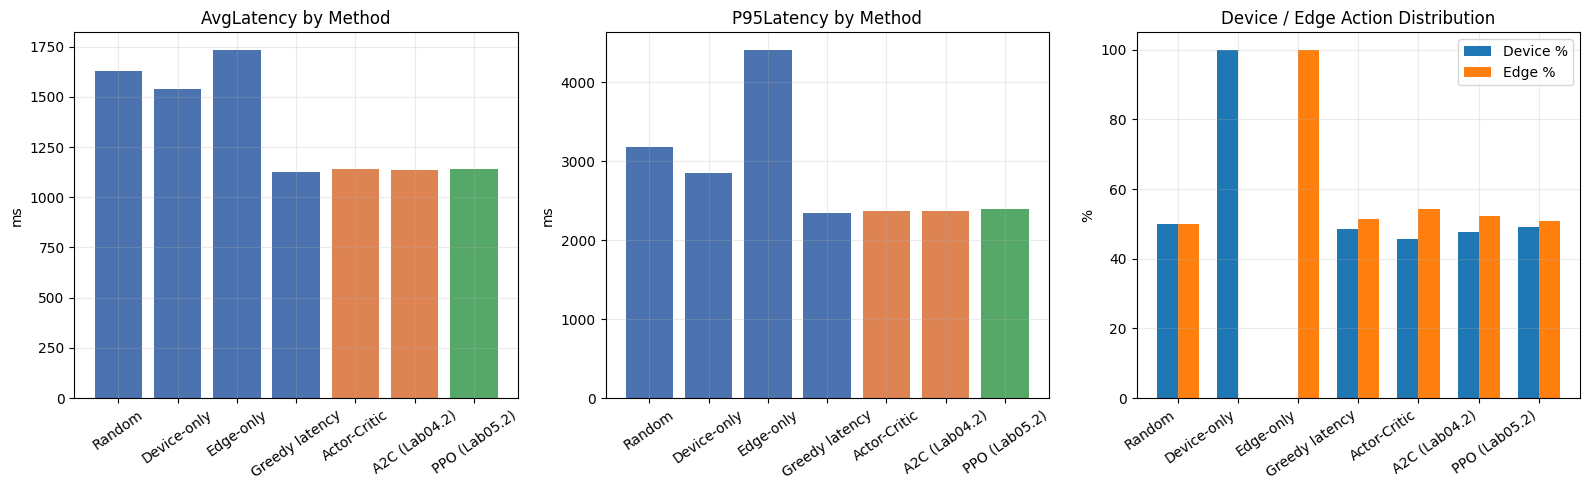

In [9]:
# ============================================================================
# Build comprehensive comparison table
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
trained_policy_results = {
    'Actor-Critic': actor_critic_result,
    'A2C (Lab04.2)': a2c_lab4_result,
    'PPO (Lab05.2)': ppo_edge_result,
}

convergence_rows = []
greedy_latency_reference = baseline_results['Greedy latency']['avg_latency']
for method_name, result in trained_policy_results.items():
    gap_to_greedy = result['avg_latency'] - greedy_latency_reference
    convergence_rows.append({
        'Method': method_name,
        'AvgLatency': result['avg_latency'],
        'GapToGreedy': gap_to_greedy,
        'Converged': (0.0 <= gap_to_greedy <= edge_convergence_gap_tolerance_ms),
    })

edge_convergence_frame = pd.DataFrame(convergence_rows).set_index('Method')
print('\nTRAINED POLICY CONVERGENCE CHECK')
print(edge_convergence_frame.round(3).to_string())
if not bool(edge_convergence_frame['Converged'].all()):
    raise RuntimeError('At least one trained policy has not empirically converged enough for fair comparison. Increase training budget before running the final table.')

comparison_rows = []


def add_result(method_name, result):
    comparison_rows.append({
        'Method': method_name,
        'AvgLatency': result['avg_latency'],
        'P95Latency': result['p95_latency'],
        'AvgReward': result['avg_reward'],
        'StdReturn': float(np.std(result['episode_rewards'])),
        'MaxReturn': float(np.max(result['episode_rewards'])),
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
        'GapToGreedy': result['avg_latency'] - baseline_results['Greedy latency']['avg_latency'],
    })


for method_name, result in baseline_results.items():
    add_result(method_name, result)

for method_name, result in trained_policy_results.items():
    add_result(method_name, result)

edge_comparison_frame = pd.DataFrame(comparison_rows).set_index('Method')
print(edge_comparison_frame.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methods = edge_comparison_frame.index.tolist()
avg_latency_values = edge_comparison_frame['AvgLatency'].values
p95_latency_values = edge_comparison_frame['P95Latency'].values
device_values = edge_comparison_frame['Device %'].values
edge_values = edge_comparison_frame['Edge %'].values
colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#DD8452', '#DD8452', '#55A868']

axes[0].bar(methods, avg_latency_values, color=colors)
axes[0].set_title('AvgLatency by Method')
axes[0].set_ylabel('ms')
axes[0].tick_params(axis='x', rotation=35)

axes[1].bar(methods, p95_latency_values, color=colors)
axes[1].set_title('P95Latency by Method')
axes[1].set_ylabel('ms')
axes[1].tick_params(axis='x', rotation=35)

x = np.arange(len(methods))
width = 0.35
axes[2].bar(x - width / 2, device_values, width, label='Device %')
axes[2].bar(x + width / 2, edge_values, width, label='Edge %')
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=35, ha='right')
axes[2].set_title('Device / Edge Action Distribution')
axes[2].set_ylabel('%')
axes[2].legend()

plt.tight_layout()
plt.show()


## CONGRATULATIONS TEAM!

Congratulations on Completing **Lab 05.2 – Continuous and Policy-Based RL with DDPG and PPO**!

**Key Conclusions:**

- You successfully designed and validated an **EdgeOffloadingEnv** that models realistic latency-aware offloading decisions.
- Baseline policies (random, device-only, edge-only, greedy) provided strong reference points for RL performance.
- **Actor-Critic/A2C-style methods** improved learning stability versus pure policy-gradient updates.
- **PPO** demonstrated robust and sample-efficient policy improvement through clipped objective optimization.
- Across experiments, learned policies captured the core trade-off between **local execution cost** and **edge transmission/queue delay**.

**Why This Lab Is Important:**

- It connects RL theory to a practical networking scenario: adaptive edge offloading.
- It shows how policy-based methods can outperform static heuristics in dynamic environments.
- It builds a strong foundation for deploying more advanced RL approaches in real-world edge/cloud systems.

### References

- Schulman et al., Proximal Policy Optimization Algorithms, arXiv:1707.06347
- Schulman et al., High-Dimensional Continuous Control Using GAE, ICLR 2016
- PyTorch documentation: https://pytorch.org/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026